Saving archive.zip to archive (2).zip
✅ Dataset Loaded


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21



Shape: (1025, 14)

Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


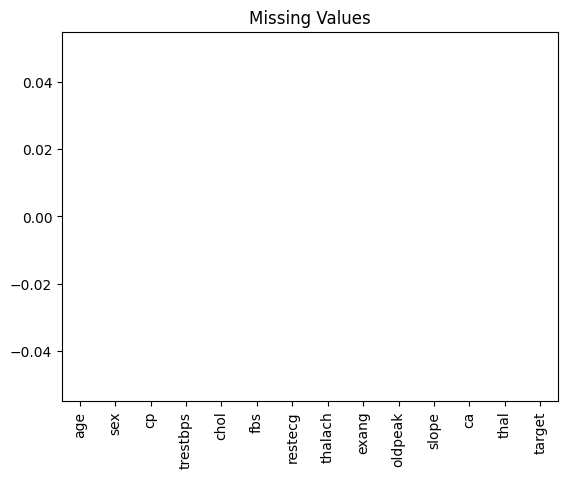


✅ Accuracy: {'Logistic Regression': 0.44878048780487806, 'Random Forest': 0.5365853658536586, 'SVM': 0.4975609756097561}


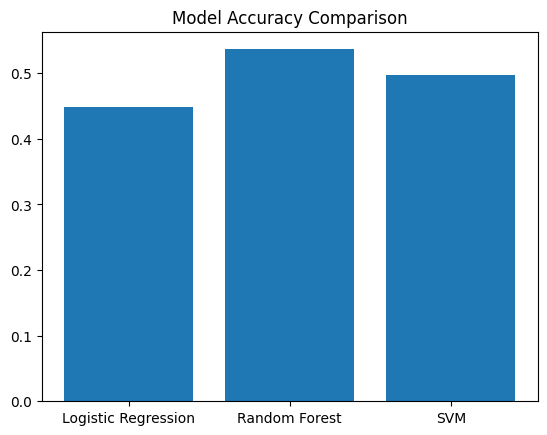

🏆 Best Model: Random Forest


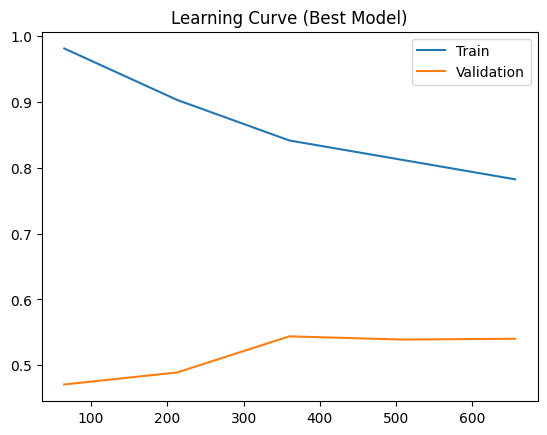

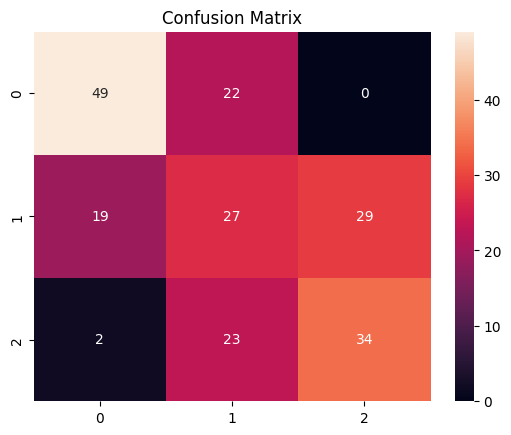

✅ Model Saved Successfully


In [ ]:
# =========================================
# 0. IMPORTS (IMPORTANT FIX 🔥)
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from google.colab import files
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)

# =========================================
# 1. UPLOAD DATASET
# =========================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("✅ Dataset Loaded")
display(df.head())

# =========================================
# 2. DATASET OVERVIEW
# =========================================
print("\nShape:", df.shape)
print("\nColumns:", df.columns)

plt.figure()
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.show()

# =========================================
# 3. CLEANING
# =========================================
df = df.copy()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# =========================================
# 4. TARGET FIX
# =========================================
target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

if y.nunique() > 10:
    y = pd.qcut(y, q=3, labels=[0,1,2])
    y = y.astype(int)

# =========================================
# 5. SPLIT + SCALING
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# 6. TRAIN MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

print("\n✅ Accuracy:", results)

# =========================================
# 7. ACCURACY COMPARISON
# =========================================
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.show()

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("🏆 Best Model:", best_model_name)

# =========================================
# 8. LEARNING CURVE
# =========================================
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.legend()
plt.title("Learning Curve (Best Model)")
plt.show()

# =========================================
# 9. CONFUSION MATRIX
# =========================================
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================================
# 10. SAVE MODEL 🔥
# =========================================
pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Model Saved Successfully")

In [ ]:
import pickle

pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [ ]:
print(X.shape)

(1025, 13)


In [ ]:
num_features = 13

In [8]:
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))